# 01. 데이터 전처리 & EDA
**산출물**: `data_clean.parquet` (train + test 동일 전처리 적용)

처리 순서:
1. 데이터 로드 & 기본 확인
2. EDA (결측률, 분포, 타겟 관계)
3. 제거 컬럼 결정 (결측 84%+, 분산=0)
4. 횟수 문자열 → 정수 변환
5. 범주형 기본 인코딩
6. 결측치 처리
7. parquet 저장

In [23]:
# 지금 당장 터미널/노트북에서 실행
import pandas as pd

# 오늘 저장된 파일 확인
df = pd.read_parquet('train_clean.parquet')

# 핵심 컬럼들의 NaN 개수 확인
critical_cols = ['총 생성 배아 수', '미세주입된 난자 수', '이식된 배아 수',
                 '저장된 배아 수', '해동된 배아 수', '수집된 신선 난자 수']
print("NaN 개수 (수정 반영 시 0보다 커야 정상):")
for col in critical_cols:
    if col in df.columns:
        print(f"  {col}: {df[col].isnull().sum():,}개")

# 예상 NaN 개수 (원본 기준):
# 총 생성 배아 수: 약 6,291개 (DI 시술)
# 이식된 배아 수: 수천 개
# 저장된 배아 수: 수만 개

NaN 개수 (수정 반영 시 0보다 커야 정상):
  총 생성 배아 수: 6,291개
  미세주입된 난자 수: 6,291개
  이식된 배아 수: 6,291개
  저장된 배아 수: 6,291개
  해동된 배아 수: 6,291개
  수집된 신선 난자 수: 6,291개


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = './이번대회자료/data/'
TARGET = '임신 성공 여부'

## 1. 데이터 로드

In [11]:
import os

DATA_DIR = './data/'
print(os.listdir(DATA_DIR))

train_raw = pd.read_csv(DATA_DIR + 'train.csv', encoding='utf-8-sig')
test_raw  = pd.read_csv(DATA_DIR + 'test.csv',  encoding='utf-8-sig')

print(f'train: {train_raw.shape}  test: {test_raw.shape}')
print(f'target 분포:\n{train_raw[TARGET].value_counts(normalize=True).round(3)}')
train_raw.head(3)

['test.csv', 'train.csv', '데이터 명세.xlsx', 'sample_submission.csv']
train: (256351, 69)  test: (90067, 68)
target 분포:
임신 성공 여부
0    0.742
1    0.258
Name: proportion, dtype: float64


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0


## 2. EDA

=== 결측률 상위 20개 ===
난자 해동 경과일                99.4%
PGS 시술 여부                99.2%
PGD 시술 여부                99.1%
착상 전 유전 검사 사용 여부         98.9%
임신 시도 또는 마지막 임신 경과 연수    96.3%
배아 해동 경과일                84.3%
난자 채취 경과일                22.4%
난자 혼합 경과일                21.0%
배아 이식 경과일                17.0%
총 생성 배아 수                 2.5%
저장된 신선 난자 수               2.5%
기증자 정자와 혼합된 난자 수          2.5%
파트너 정자와 혼합된 난자 수          2.5%
혼합된 난자 수                  2.5%
해동 난자 수                   2.5%
수집된 신선 난자 수               2.5%
이식된 배아 수                  2.5%
배아 생성 주요 이유               2.5%
해동된 배아 수                  2.5%
미세주입 배아 이식 수              2.5%
dtype: str


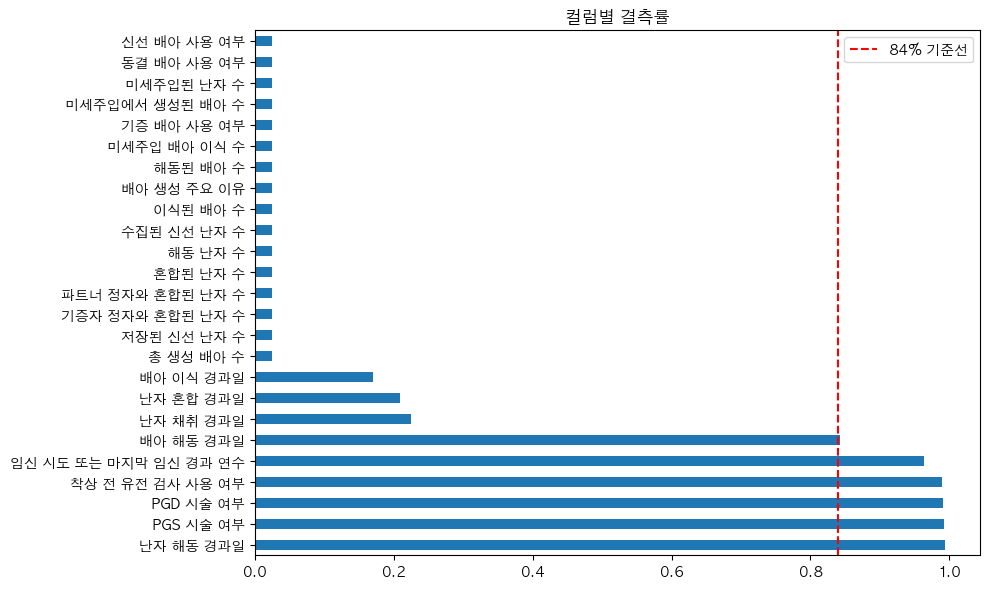

In [12]:
# ── 결측률 확인 ──
missing = train_raw.isnull().mean().sort_values(ascending=False)
print("=== 결측률 상위 20개 ===")
print(missing[missing > 0].head(20).apply(lambda x: f'{x:.1%}'))

fig, ax = plt.subplots(figsize=(10, 6))
missing[missing > 0].head(25).plot(kind='barh', ax=ax)
ax.axvline(0.84, color='red', linestyle='--', label='84% 기준선')
ax.legend()
ax.set_title('컬럼별 결측률')
plt.tight_layout()
plt.show()

In [13]:
# ── 수치형 분산 0 확인 ──
num_cols = train_raw.select_dtypes(include='number').columns.tolist()
zero_var_cols = [c for c in num_cols if train_raw[c].var() == 0]
print('분산=0 컬럼:', zero_var_cols)

분산=0 컬럼: ['착상 전 유전 검사 사용 여부', '불임 원인 - 여성 요인', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일']


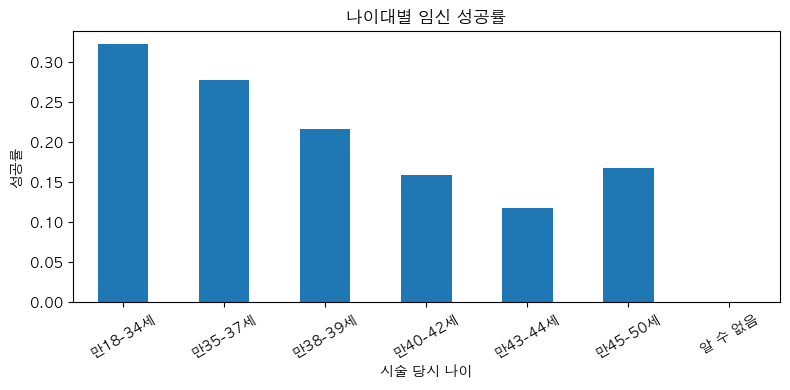

In [14]:
# ── 타겟별 나이 분포 ──
age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
age_success = train_raw.groupby('시술 당시 나이')[TARGET].mean().reindex(age_order)
age_success.plot(kind='bar', figsize=(8, 4), title='나이대별 임신 성공률')
plt.ylabel('성공률')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
# ── 시술 유형별 성공률 ──
print(train_raw.groupby('시술 유형')[TARGET].agg(['mean', 'count']).round(3))

        mean   count
시술 유형               
DI     0.129    6291
IVF    0.262  250060


## 3. 제거 컬럼 결정

In [16]:
# 결측 84% 이상
DROP_HIGH_MISSING = missing[missing >= 0.84].index.tolist()

# 분산 = 0 (타겟 제외)
DROP_ZERO_VAR = [c for c in zero_var_cols if c != TARGET]

# ID는 학습에 사용 안 함 (제거 X, 보존해서 제출용)
DROP_COLS = list(set(DROP_HIGH_MISSING + DROP_ZERO_VAR))

print(f'제거 컬럼 ({len(DROP_COLS)}개):')
for c in sorted(DROP_COLS):
    reason = '결측84%+' if c in DROP_HIGH_MISSING else '분산=0'
    print(f'  [{reason}] {c}')

제거 컬럼 (8개):
  [결측84%+] PGD 시술 여부
  [결측84%+] PGS 시술 여부
  [분산=0] 난자 채취 경과일
  [결측84%+] 난자 해동 경과일
  [결측84%+] 배아 해동 경과일
  [분산=0] 불임 원인 - 여성 요인
  [결측84%+] 임신 시도 또는 마지막 임신 경과 연수
  [결측84%+] 착상 전 유전 검사 사용 여부


## 4. 횟수 문자열 → 정수 변환

In [17]:
COUNT_COLS = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수',
    'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수',
]

def parse_count(series: pd.Series) -> pd.Series:
    """'N회' 문자열을 정수로 변환. '6회 이상'은 6으로 통일."""
    return (
        series.str.extract(r'(\d+)')[0]
        .astype(float)
        .astype('Int64')  # nullable integer (NA 보존)
    )

def convert_count_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in COUNT_COLS:
        if col in df.columns:
            is_censored = df[col].str.contains('이상', na=False).astype(int)
            df[col + '_censored'] = is_censored  # '6회 이상' 플래그
            df[col] = parse_count(df[col])
    return df

# 확인
sample = train_raw[COUNT_COLS].head(3)
print('변환 전:\n', sample.to_string())
sample_converted = convert_count_cols(sample)
print('\n변환 후:\n', sample_converted[[c for c in sample_converted.columns if '_censored' not in c]].to_string())

변환 전:
   총 시술 횟수 클리닉 내 총 시술 횟수 IVF 시술 횟수 DI 시술 횟수 총 임신 횟수 IVF 임신 횟수 DI 임신 횟수 총 출산 횟수 IVF 출산 횟수 DI 출산 횟수
0      0회            0회        0회       0회      0회        0회       0회      0회        0회       0회
1      0회            0회        0회       0회      0회        0회       0회      0회        0회       0회
2      1회            0회        1회       0회      0회        0회       0회      0회        0회       0회

변환 후:
    총 시술 횟수  클리닉 내 총 시술 횟수  IVF 시술 횟수  DI 시술 횟수  총 임신 횟수  IVF 임신 횟수  DI 임신 횟수  총 출산 횟수  IVF 출산 횟수  DI 출산 횟수
0        0              0          0         0        0          0         0        0          0         0
1        0              0          0         0        0          0         0        0          0         0
2        1              0          1         0        0          0         0        0          0         0


## 5. 범주형 기본 처리

In [18]:
AGE_ORDER = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
AGE_MAP   = {v: i for i, v in enumerate(AGE_ORDER)}  # 0~6 서수

def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 나이: '알 수 없음'은 NaN으로!
    AGE_MAP_FIXED = {
        '만18-34세': 0, '만35-37세': 1, '만38-39세': 2,
        '만40-42세': 3, '만43-44세': 4, '만45-50세': 5,
        '알 수 없음': np.nan  # ← 최대값 6이 아니라 NaN으로
    }
    df['알 수 없음'] = (df['시술 당시 나이'] == '알 수 없음').astype(int)
    df['시술 당시 나이'] = df['시술 당시 나이'].map(AGE_MAP_FIXED)  # Int64 아닌 float 유지
    df['나이_35초과'] = (df['시술 당시 나이'] >= 1).astype('Int8')  # NaN 보존  # index 2 = 만35-37세 이상

    # 시술 유형: IVF=1, DI=0
    df['is_IVF'] = (df['시술 유형'] == 'IVF').astype(int)
    df['is_DI']  = (df['시술 유형'] == 'DI').astype(int)

    # 배란 유도 유형 — 알수없음/기록없음 → 0/1
    df['배란유도_알수없음'] = (df['배란 유도 유형'].isin(['알 수 없음'])).astype(int)

    # 난자/정자 출처 → 이진
    df['난자_기증'] = (df['난자 출처'] != '본인 제공').astype(int)
    df['정자_기증'] = (df['정자 출처'] != '배우자 제공').astype(int)

    # 배아 생성 주요 이유 → 멀티핫
    df['is_현재시술용'] = df['배아 생성 주요 이유'].str.contains('현재 시술용', na=False).astype(int)
    df['is_기증용']     = df['배아 생성 주요 이유'].str.contains('기증용', na=False).astype(int)
    df['is_배아저장용'] = df['배아 생성 주요 이유'].str.contains('배아저장용', na=False).astype(int)

    return df

# 확인
tmp = encode_categorical(train_raw.head(5))
new_cols = ['시술 당시 나이', '알 수 없음', '나이_35초과', 'is_IVF', 'is_DI', '난자_기증', '정자_기증']
print(tmp[new_cols].to_string())

   시술 당시 나이  알 수 없음  나이_35초과  is_IVF  is_DI  난자_기증  정자_기증
0       0.0       0        0       1      0      0      0
1       5.0       0        1       1      0      0      0
2       0.0       0        0       1      0      0      0
3       1.0       0        1       1      0      0      0
4       0.0       0        0       1      0      0      0


## 6. 결측치 처리

In [19]:
import pandas as pd

def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 배아/난자 수치형 — NaN 플래그만 생성, 값은 그대로 두기
    embryo_num_cols = [
        '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
        '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
        '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
        '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수',
        '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수',
    ]
    for col in embryo_num_cols:
        if col in df.columns:
            df[col + '_missing'] = df[col].isnull().astype(int)
    
    if '임신 시도 또는 마지막 임신 경과 연수' in df.columns:
        df['임신경과연수_missing'] = df['임신 시도 또는 마지막 임신 경과 연수'].isnull().astype(int)
    
    if '단일 배아 이식 여부' in df.columns:
        df['단일배아_missing'] = df['단일 배아 이식 여부'].isnull().astype(int)
    
    infertility_bool_cols = [c for c in df.columns if '불임 원인 -' in c]
    df[infertility_bool_cols] = df[infertility_bool_cols].fillna(0).astype(int)
    
    return df


## 7. 전체 파이프라인 실행 & 저장

In [20]:
def full_preprocess(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    df = df.copy()

    # 제거
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # 횟수 변환
    df = convert_count_cols(df)

    # 범주형 인코딩
    df = encode_categorical(df)

    # 결측 처리
    df = handle_missing(df)

    return df


train_clean = full_preprocess(train_raw, is_train=True)
test_clean  = full_preprocess(test_raw,  is_train=False)

print(f'train_clean: {train_clean.shape}')
print(f'test_clean:  {test_clean.shape}')
print(f'잔여 결측률 상위5:\n{train_clean.isnull().mean().sort_values(ascending=False).head(5)}')

train_clean: (256351, 96)
test_clean:  (90067, 95)
잔여 결측률 상위5:
난자 혼합 경과일          0.209615
배아 이식 경과일          0.169947
해동 난자 수            0.024541
미세주입된 난자 수         0.024541
미세주입에서 생성된 배아 수    0.024541
dtype: float64


In [21]:
train_clean.to_parquet('train_clean.parquet', index=False)
test_clean.to_parquet('test_clean.parquet', index=False)
print('저장 완료: train_clean.parquet, test_clean.parquet')

저장 완료: train_clean.parquet, test_clean.parquet


In [22]:
# ── 저장 검증 ──
df_check = pd.read_parquet('train_clean.parquet')
print('로드 확인:', df_check.shape)
print('컬럼 목록:')
for i, c in enumerate(df_check.columns, 1):
    print(f'  {i:02d}. {c}')

로드 확인: (256351, 96)
컬럼 목록:
  01. ID
  02. 시술 시기 코드
  03. 시술 당시 나이
  04. 시술 유형
  05. 특정 시술 유형
  06. 배란 자극 여부
  07. 배란 유도 유형
  08. 단일 배아 이식 여부
  09. 착상 전 유전 진단 사용 여부
  10. 남성 주 불임 원인
  11. 남성 부 불임 원인
  12. 여성 주 불임 원인
  13. 여성 부 불임 원인
  14. 부부 주 불임 원인
  15. 부부 부 불임 원인
  16. 불명확 불임 원인
  17. 불임 원인 - 난관 질환
  18. 불임 원인 - 남성 요인
  19. 불임 원인 - 배란 장애
  20. 불임 원인 - 자궁경부 문제
  21. 불임 원인 - 자궁내막증
  22. 불임 원인 - 정자 농도
  23. 불임 원인 - 정자 면역학적 요인
  24. 불임 원인 - 정자 운동성
  25. 불임 원인 - 정자 형태
  26. 배아 생성 주요 이유
  27. 총 시술 횟수
  28. 클리닉 내 총 시술 횟수
  29. IVF 시술 횟수
  30. DI 시술 횟수
  31. 총 임신 횟수
  32. IVF 임신 횟수
  33. DI 임신 횟수
  34. 총 출산 횟수
  35. IVF 출산 횟수
  36. DI 출산 횟수
  37. 총 생성 배아 수
  38. 미세주입된 난자 수
  39. 미세주입에서 생성된 배아 수
  40. 이식된 배아 수
  41. 미세주입 배아 이식 수
  42. 저장된 배아 수
  43. 미세주입 후 저장된 배아 수
  44. 해동된 배아 수
  45. 해동 난자 수
  46. 수집된 신선 난자 수
  47. 저장된 신선 난자 수
  48. 혼합된 난자 수
  49. 파트너 정자와 혼합된 난자 수
  50. 기증자 정자와 혼합된 난자 수
  51. 난자 출처
  52. 정자 출처
  53. 난자 기증자 나이
  54. 정자 기증자 나이
  55. 동결 배아 사용 여부
  56. 신선 배아 사용 여부
  57. 기증 배아 사